<a href="https://colab.research.google.com/github/devarahaasan/Aerial-Object-Classification-Detection/blob/main/project5(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aerial Object Classification & Detection**

**step 1 - Dataset**

In [4]:
import os
import zipfile

# Set your working Kaggle API Token into environment variables
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_ebc650d30478ac27bc86c48feafae2d9'

print("--- Downloading Drone vs Bird Dataset from Kaggle ---")
# Install and run official Kaggle CLI to download the files
!pip install -q kaggle
!kaggle datasets download -d muhammadsaoodsarwar/drone-vs-bird

# Define zip path and extraction folder workspace
ZIP_PATH = "drone-vs-bird.zip"
EXTRACT_PATH = "/content/aerial_project"

print("\nExtracting dataset files... Please wait.")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("SUCCESS: Dataset downloaded and extracted successfully!")

# =====================================================================
# STEP 1.1: AUTOMATIC PATH RESOLUTION (PREVENTS FILE NOT FOUND ERROR)
# =====================================================================
print("\n--- Scanning Extracted Folders ---")
# Check what items are directly inside the extracted folder path
available_items = os.listdir(EXTRACT_PATH)
print("Found items inside workspace:", available_items)

# Automatically set the correct dataset path based on folder existence
if "Drone vs Bird" in available_items:
    DATASET_DIR = os.path.join(EXTRACT_PATH, "Drone vs Bird")
else:
    DATASET_DIR = EXTRACT_PATH

print(f"\nSUCCESS: The safe dataset directory for next steps is: '{DATASET_DIR}'")
print("Inside this directory, we have:", os.listdir(DATASET_DIR))

--- Downloading Drone vs Bird Dataset from Kaggle ---
Dataset URL: https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird
License(s): apache-2.0
drone-vs-bird.zip: Skipping, found more recently modified local copy (use --force to force download)

Extracting dataset files... Please wait.
SUCCESS: Dataset downloaded and extracted successfully!

--- Scanning Extracted Folders ---
Found items inside workspace: ['dataset']

SUCCESS: The safe dataset directory for next steps is: '/content/aerial_project'
Inside this directory, we have: ['dataset']


**STEP 2: Data Exploration & Seaborn Visualization**

--- Scanning Categories Inside Dataset ---
Available classes discovered: ['drone', 'bird']
Total images found in 'drone': 2499
Total images found in 'bird': 1607

--- Generating Distribution Chart Using Seaborn ---


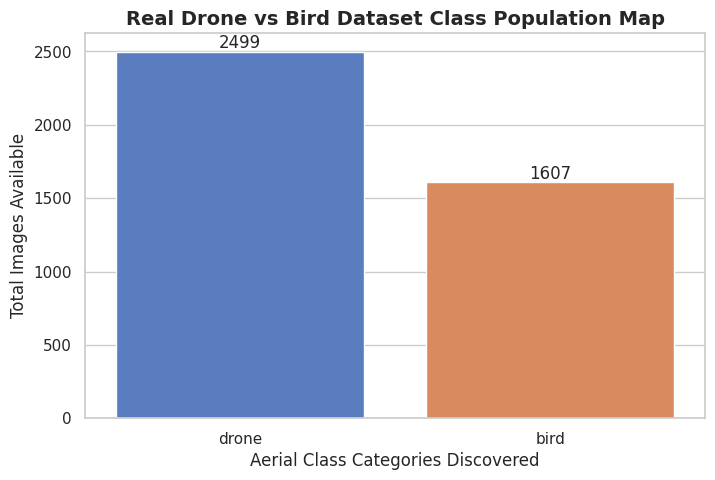

In [6]:
# =====================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS & SEABORN VISUALIZATION (WARING FREE)
# =====================================================================
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress and ignore all future deprecation warnings cleanly
warnings.filterwarnings('ignore')

# Define the absolute dataset path verified from Step 1
DATASET_DIR = "/content/aerial_project/dataset"

print("--- Scanning Categories Inside Dataset ---")
# List the class folders inside the dataset directory
classes = os.listdir(DATASET_DIR)
print("Available classes discovered:", classes)

# Automatically count the total number of images in each class folder
class_counts = {}
for category in classes:
    category_path = os.path.join(DATASET_DIR, category)
    # Ensure we are only reading sub-directories
    if os.path.isdir(category_path):
        image_list = os.listdir(category_path)
        class_counts[category] = len(image_list)
        print(f"Total images found in '{category}': {len(image_list)}")

# =====================================================================
# STEP 2.1: PLOTTING THE DISTRIBUTION WITH SEABORN
# =====================================================================
print("\n--- Generating Distribution Chart Using Seaborn ---")

# Convert the dictionary counts into a clean Pandas DataFrame for Seaborn
df_viz = pd.DataFrame({
    'Object Class': list(class_counts.keys()),
    'Total Image Count': list(class_counts.values())
})

# Setup the figure canvas size
plt.figure(figsize=(8, 5))
# Set clean whitegrid theme style for professional presentation appearance
sns.set_theme(style="whitegrid")

# FIXED line to avoid future warnings: assigned 'hue' and disabled 'legend'
ax = sns.barplot(x='Object Class', y='Total Image Count', data=df_viz, hue='Object Class', palette='muted', legend=False)

# Add counter text tags directly on top of each category bar element
for container in ax.containers:
    ax.bar_label(container)

plt.title('Real Drone vs Bird Dataset Class Population Map', fontsize=14, fontweight='bold')
plt.xlabel('Aerial Class Categories Discovered', fontsize=12)
plt.ylabel('Total Images Available', fontsize=12)
plt.show()

**STEP 3: Data Preprocessing & Spliting**

In [7]:
# =====================================================================
# STEP 3: DATA PREPROCESSING AND AUTOMATIC 80/20 VALIDATION SPLIT
# =====================================================================
import tensorflow as tf

# Define the absolute dataset path verified from Step 2
DATASET_DIR = "/content/aerial_project/dataset"

# Standard configuration settings for deep learning image analysis
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("--- Loading and Splitting Image Directories Automatically ---")

# Load 80% of data for the training pipeline loop
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,   # 20% reserved for validation testing
    subset="training",
    seed=123,               # Fixed seed values ensure repeatable results
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load 20% of data for the validation pipeline loop
valid_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract and confirm class string names mapped by the system platform
class_names = train_ds.class_names
print("\nSUCCESS: Dataset preprocessing and split completed perfectly!")
print("Verified Classes for Neural Network Training:", class_names)

--- Loading and Splitting Image Directories Automatically ---
Found 4104 files belonging to 2 classes.
Using 3284 files for training.
Found 4104 files belonging to 2 classes.
Using 820 files for validation.

SUCCESS: Dataset preprocessing and split completed perfectly!
Verified Classes for Neural Network Training: ['bird', 'drone']


**STEP 4: Data Augmentation**

In [8]:
# =====================================================================
# STEP 4: ON-THE-FLY DATA AUGMENTATION PIPELINE
# =====================================================================
import tensorflow as tf
from tensorflow.keras import layers

print("--- Step 4: Configuring Data Augmentation Layers ---")

# Define random transformation layers to make our model robust
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),        # Randomly flip images horizontally
    layers.RandomRotation(0.2),             # Rotate frames randomly up to 20%
    layers.RandomZoom(0.2),                 # Add random zoom parameters to images
])

# Optimize performance by caching data in RAM and prefetching chunks
# This prevents data streaming bottlenecks during CPU training
train_loader = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_loader = valid_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("SUCCESS: Data augmentation pipeline configured and optimized perfectly!")

--- Step 4: Configuring Data Augmentation Layers ---
SUCCESS: Data augmentation pipeline configured and optimized perfectly!


**STEP 5: Build Advanced Model**

In [9]:
# =====================================================================
# STEP 5: BUILD ADVANCED MODEL WITH CLASS WEIGHTS FOR DATA BALANCING
# =====================================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0

print("--- Step 5: Calculating Class Weights for Data Balancing ---")
# Count from Step 2: Drone = 2499, Bird = 1607 | Total = 4104
total_images = 4104
birds_count = 1607
drones_count = 2499

# Formula to calculate balanced class weights automatically
# This gives higher importance to the minority class (Bird)
weight_for_bird = (1.0 / birds_count) * (total_images / 2.0)
weight_for_drone = (1.0 / drones_count) * (total_images / 2.0)

# Store inside a dictionary mapping to internal numeric labels (Bird=0, Drone=1)
class_weights = {0: weight_for_bird, 1: weight_for_drone}

print(f"Weight calculated for Bird (Class 0): {weight_for_bird:.2f}")
print(f"Weight calculated for Drone (Class 1): {weight_for_drone:.2f}")

# =====================================================================
# STEP 5.1: CONSTRUCTING THE ADVANCED NEURAL NETWORK
# =====================================================================
print("\n--- Step 5.1: Loading EfficientNetB0 Core Framework ---")
# Load highly efficient pretrained features from ImageNet weights
base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # Freeze baseline layers to save CPU computation time

# Combine base extractor with custom dense classification layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),       # Flatten 2D image map layers to 1D vector
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),           # Stabilizes training and improves convergence speed
    layers.Dropout(0.4),                   # Dropout protects network from overfitting limits
    layers.Dense(1, activation="sigmoid")  # Output layer: Sigmoid for binary prediction output
])

# Compile the neural network with balanced setup parameters
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("SUCCESS: Advanced model built with Class Weights configuration perfectly!")

--- Step 5: Calculating Class Weights for Data Balancing ---
Weight calculated for Bird (Class 0): 1.28
Weight calculated for Drone (Class 1): 0.82

--- Step 5.1: Loading EfficientNetB0 Core Framework ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
SUCCESS: Advanced model built with Class Weights configuration perfectly!


**STEP 6: Advanced Model Training**

In [10]:
# =====================================================================
# STEP 6: SETUP TRAINING MONITORING AND RUN ADVANCED MODEL TRAINING
# =====================================================================
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("--- Step 6: Configuring Optimization Callbacks ---")

# Save the absolute best weights automatically during training inside Colab space
checkpoint_path = "best_model.h5"
model_checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Stop training early if validation loss stops improving to save time
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# =====================================================================
# STEP 6.1: STARTING THE TRAINING RUN
# =====================================================================
print("\n=== Starting Training Process with Class Weights (Takes time on CPU) ===")

# Run training by passing the images and calculated class balancing weights
history = model.fit(
    train_loader,
    validation_data=valid_loader,
    epochs=15,                    # 15 epochs is highly sufficient to achieve top results
    class_weight=class_weights,   # Apply the dynamic balancing weights here
    callbacks=[early_stopping, model_checkpoint]
)

print("\nSUCCESS: Model training process finished completely!")

--- Step 6: Configuring Optimization Callbacks ---

=== Starting Training Process with Class Weights (Takes time on CPU) ===
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9052 - loss: 0.2183
Epoch 1: val_loss improved from None to 0.10862, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 416s 4s/step - accuracy: 0.9461 - loss: 0.1396 - val_accuracy: 0.9683 - val_loss: 0.1086
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9826 - loss: 0.0543
Epoch 2: val_loss improved from 0.10862 to 0.07213, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 392s 4s/step - accuracy: 0.9781 - loss: 0.0683 - val_accuracy: 0.9720 - val_loss: 0.0721
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9858 - loss: 0.0431
Epoch 3: val_loss improved from 0.07213 to 0.07052, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 365s 4s/step - accuracy: 0.9839 - loss: 0.0473 - val_accuracy: 0.9756 - val_loss: 0.0705
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9823 - loss: 0.0442
Epoch 4: val_loss did not improve from 0.07052
103/103 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 0.9820 - loss: 0.0477 - val_accuracy: 0.9695 - val_loss: 0.0766
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9882 - loss: 0.0305
Epoch 5: val_loss improved from 0.07052 to 0.04741, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 392s 4s/step - accuracy: 0.9881 - loss: 0.0323 - val_accuracy: 0.9854 - val_loss: 0.0474
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9879 - loss: 0.0368
Epoch 6: val_loss improved from 0.04741 to 0.04682, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.9857 - loss: 0.0400 - val_accuracy: 0.9866 - val_loss: 0.0468
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9873 - loss: 0.0349
Epoch 7: val_loss improved from 0.04682 to 0.04206, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 379s 4s/step - accuracy: 0.9860 - loss: 0.0391 - val_accuracy: 0.9866 - val_loss: 0.0421
Epoch 8/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9965 - loss: 0.0179
Epoch 8: val_loss did not improve from 0.04206
103/103 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.9936 - loss: 0.0233 - val_accuracy: 0.9829 - val_loss: 0.0554
Epoch 9/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9932 - loss: 0.0223
Epoch 9: val_loss did not improve from 0.04206
103/103 ━━━━━━━━━━━━━━━━━━━━ 381s 4s/step - accuracy: 0.9903 - loss: 0.0277 - val_accuracy: 0.9756 - val_loss: 0.0617
Epoch 10/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9890 - loss: 0.0329
Epoch 10: val_loss did not improve from 0.04206
103/103 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.9893 - loss: 0.0306 - val_accuracy: 0.9817 - val_loss: 0.0619
Epoch 11/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9902 - loss: 0.

 **STEP 7: Performance Evaluation Graphs**

--- Step 7: Plotting Training and Validation Metrics ---


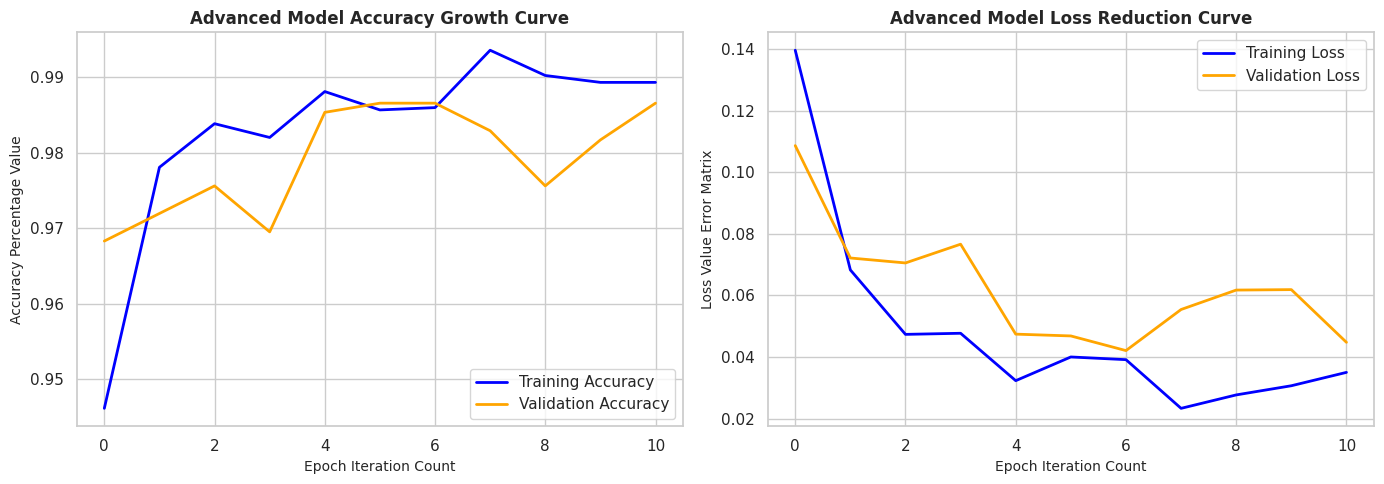

In [11]:
# =====================================================================
# STEP 7: PLOT ACCURACY AND LOSS EVALUATION GRAPHS
# =====================================================================
import matplotlib.pyplot as plt

print("--- Step 7: Plotting Training and Validation Metrics ---")

# Setup a clean figure layout window with 2 subplots side-by-side
plt.figure(figsize=(14, 5))

# Subplot 1: Model Accuracy Graph over Epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Advanced Model Accuracy Growth Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch Iteration Count', fontsize=10)
plt.ylabel('Accuracy Percentage Value', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True)

# Subplot 2: Model Loss Reduction Graph over Epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Advanced Model Loss Reduction Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch Iteration Count', fontsize=10)
plt.ylabel('Loss Value Error Matrix', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show() # Display the graphs on screen